# INSTALASI PACKAGE


In [4]:
pip install ucimlrepo

# PEMANGGILAN LIBRARY


In [12]:
import ucimlrepo

# MELIHAT DATASET YANG DISEDIAKAN

In [13]:
dir(ucimlrepo)

['API_BASE_URL',
 'API_LIST_URL',
 'DATASET_FILE_BASE_URL',
 'DatasetNotFoundError',
 'Optional',
 'VALID_FILTERS',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 'certifi',
 'dotdict',
 'fetch',
 'fetch_ucirepo',
 'json',
 'list_available_datasets',
 'pd',
 'ssl',
 'urllib']

In [14]:
from ucimlrepo import list_available_datasets

In [22]:
data = list_available_datasets()

-------------------------------------
The following datasets are available:
-------------------------------------
Dataset Name                                                                            ID    
------------                                                                            --    
Abalone                                                                                 1     
Adult                                                                                   2     
Annealing                                                                               3     
Audiology (Standardized)                                                                8     
Auto MPG                                                                                9     
Automobile                                                                              10    
Balance Scale                                                                           12    
Balloons                       

Pada list dataset tersebut saya ingin menggunakan dataset Online Shoppers Purchasing Intention Dataset

#Import Library

In [25]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

#FECT DATA / LOAD DATA

In [27]:
data = fetch_ucirepo(id=468)

In [28]:
data

{'data': {'ids': None,
  'features':        Administrative  Administrative_Duration  Informational  \
  0                   0                      0.0              0   
  1                   0                      0.0              0   
  2                   0                      0.0              0   
  3                   0                      0.0              0   
  4                   0                      0.0              0   
  ...               ...                      ...            ...   
  12325               3                    145.0              0   
  12326               0                      0.0              0   
  12327               0                      0.0              0   
  12328               4                     75.0              0   
  12329               0                      0.0              0   
  
         Informational_Duration  ProductRelated  ProductRelated_Duration  \
  0                         0.0               1                 0.000000   
  1   

#Load Dataset

In [29]:
data = pd.read_csv("https://archive.ics.uci.edu/static/public/468/data.csv")

In [30]:
data

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.000000,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.000000,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.000000,0.0,Feb,3,3,1,4,Returning_Visitor,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12325,3,145.0,0,0.0,53,1783.791667,0.007143,0.029031,12.241717,0.0,Dec,4,6,1,1,Returning_Visitor,True,False
12326,0,0.0,0,0.0,5,465.750000,0.000000,0.021333,0.000000,0.0,Nov,3,2,1,8,Returning_Visitor,True,False
12327,0,0.0,0,0.0,6,184.250000,0.083333,0.086667,0.000000,0.0,Nov,3,2,1,13,Returning_Visitor,True,False
12328,4,75.0,0,0.0,15,346.000000,0.000000,0.021053,0.000000,0.0,Nov,2,2,3,11,Returning_Visitor,False,False


#Pra-pemrosesan Data

In [31]:
label_encoders = {}
categorical_cols = ['Month', 'VisitorType', 'Weekend']
for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le


In [93]:
data['Revenue'] = data['Revenue'].astype(int)


In [32]:
X = data.drop('Revenue', axis=1)
y = data['Revenue']


In [33]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)


#Split Data

In [35]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

#Evaluasi Model

In [100]:
y_pred = model.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nAccuracy:", accuracy_score(y_test, y_pred))


Confusion Matrix:
[[2007   77]
 [ 169  213]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.96      0.94      2084
           1       0.73      0.56      0.63       382

    accuracy                           0.90      2466
   macro avg       0.83      0.76      0.79      2466
weighted avg       0.89      0.90      0.89      2466


Accuracy: 0.9002433090024331


#Visualisasi Pentingnya Fitur

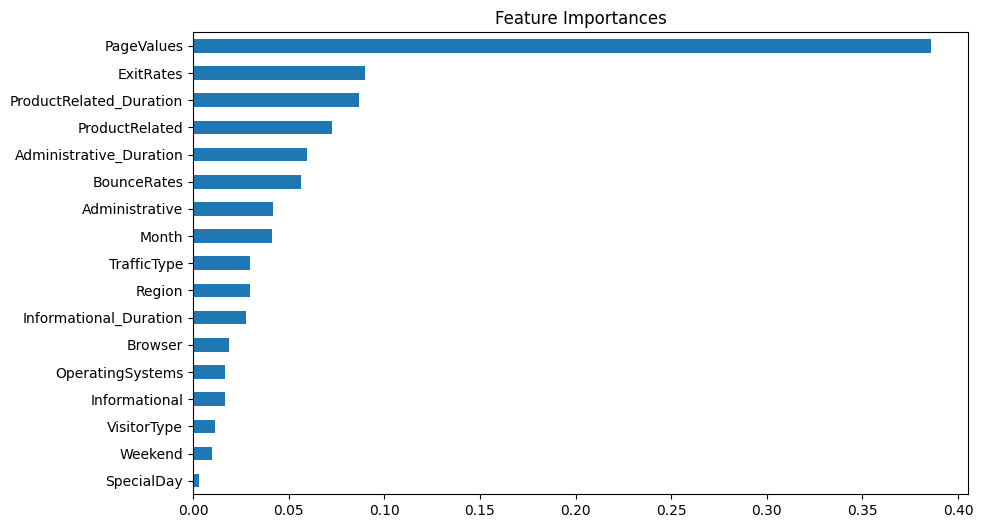

In [101]:
feature_importances = pd.Series(model.feature_importances_, index=X.columns)
feature_importances.sort_values(ascending=True).plot(kind='barh', figsize=(10,6))
plt.title("Feature Importances")
plt.show()


#visualisasi distribusi data

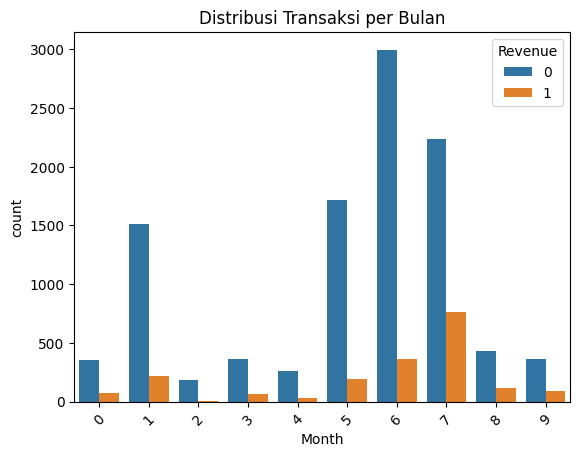

In [102]:
sns.countplot(x='Month', hue='Revenue', data=data)
plt.title("Distribusi Transaksi per Bulan")
plt.xticks(rotation=45)
plt.show()


#Oversampling dengan SMOTE

In [103]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)



#Membangun Model Klasifikasi dengan Logistic Regression

In [104]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(class_weight='balanced')
model.fit(X_train, y_train)


LogisticRegression(class_weight='balanced')

#visualisasi data berdimensi tinggi menggunakan PCA (Principal Component Analysis)

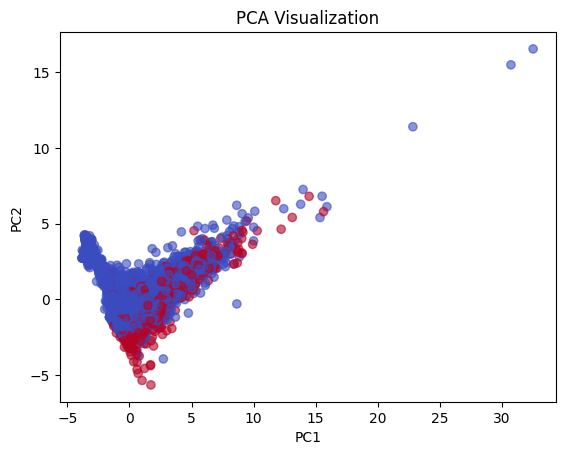

In [105]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='coolwarm', alpha=0.6)
plt.title("PCA Visualization")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


#Import library yang dibutuhkan untuk clustering, reduksi dimensi, dan visualisasi

In [106]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)
data['Cluster'] = clusters


In [36]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

#Mereduksi fitur dari X_scaled (data hasil preprocessing dan scaling) menjadi 2 dimensi utama dengan PCA, supaya bisa divisualisasikan dalam grafik 2D

In [37]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)


In [38]:
kmeans = KMeans(n_clusters=2, random_state=42)
cluster_labels = kmeans.fit_predict(X_scaled)


Membangun model K-Means dengan jumlah klaster = 2 (bisa diubah ke 3, 4, dst tergantung kebutuhan), dan menyimpan hasil prediksi klaster masing-masing data dalam cluster_labels

#Membuat visualisasi hasil klastering:

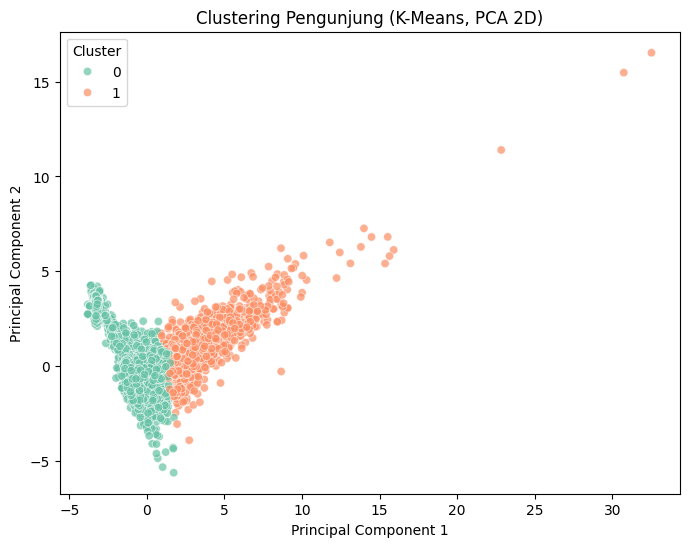

In [111]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=cluster_labels, palette='Set2', alpha=0.7)
plt.title('Clustering Pengunjung (K-Means, PCA 2D)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()


* Titik-titik mewakili pengunjung (data),

* Sumbu X dan Y adalah hasil reduksi dimensi PCA (PC1 dan PC2),

* Warna berbeda menunjukkan cluster berbeda,

* Tujuannya untuk melihat apakah klaster memang membentuk kelompok yang jelas.

